In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import statsmodels.api as sm
from utils import functions

dirpath = '/Users/kimchm/Documents/KimNiNature2024/MatConverted2Python/' 
metadata = pd.read_csv(dirpath + 'EDF10d_info_2026_01_16.csv')
CDdotprod_python = pd.read_csv('CDdotprod_python_deconvolved.txt')


# Compare CD dot products of CK and JH
metadata['Merged_ID'] = (
    metadata['Mouse ID'].str.strip("'") + '_' + 
    metadata['FOV'].str.strip("'") + '_' + 
    metadata['Session1'].str.strip("'").str.replace("-", "_") + '_' + 
    metadata['Session2'].str.strip("'").str.replace("-", "_")
)
cols = ['Merged_ID'] + [c for c in metadata.columns if c != 'Merged_ID']
metadata = metadata[cols]
metadata = metadata.sort_values(by='Merged_ID')
metadata = metadata.reset_index(drop=True)

filtered_CDdotprod_python = CDdotprod_python[CDdotprod_python['ID'].isin(metadata['Merged_ID'])].reset_index(drop=True)

is_aligned = metadata['Merged_ID'].equals(filtered_CDdotprod_python['ID'])
    
# sort by relearns speed
colname_relearn_speed = 'Relative trials to reach\n75% performance'
relearn_speed = metadata[colname_relearn_speed]
sorted_indices_by_relearn_speed = np.argsort(relearn_speed)

# sort by CD dot product
colname_CDdotproduct = 'CDdotproduct'
CDdotproduct = filtered_CDdotprod_python[colname_CDdotproduct]
sorted_indices_by_CDdotproduct = np.argsort(CDdotproduct)
# filtered_CDdotprod_sorted = filtered_CDdotprod_python.sort_values(by='CDdotproduct').reset_index(drop=True)

tsample   = 1.57
tdelay    = 2.87
tresponse = 4.17
dt        = 1/6
ntimestep = 47
tvec      = dt * np.arange(ntimestep)
tix_sample   = np.where(tvec > tsample)[0][0]
tix_delay    = np.where(tvec > tdelay)[0][0]
tix_response = np.where(tvec > tresponse)[0][0]
lickright    = 0
lickleft     = 1


In [67]:
# #--- sorted by relearn speed ---#
# fidx     = sorted_indices_by_relearn_speed[ix]    
# filename = filtered_CDdotprod_python['ID'][fidx]

#--- sorted by CD dot product ---#
nfile = len(filtered_CDdotprod_python)
opto_1_diff_all = np.zeros((nfile,ntimestep))
opto_2_diff_all = np.zeros((nfile,ntimestep))
opto_P_diff_all = np.zeros((nfile,ntimestep))
opto_A_diff_all = np.zeros((nfile,ntimestep))
for ix in range(nfile):
        
    print(ix)
    # ix = 0
    fidx = sorted_indices_by_CDdotproduct[ix]
    filename = filtered_CDdotprod_python['ID'][fidx]

    filepath = dirpath + filename + '.npy'
    data = np.load(filepath, allow_pickle=True)
    data_type = 'deconvolved'

    tsample   = 1.57
    tdelay    = 2.87
    tresponse = 4.17
    dt        = 1/6
    ntimestep = 47
    tvec      = dt * np.arange(ntimestep)
    tix_sample   = np.where(tvec > tsample)[0][0]
    tix_delay    = np.where(tvec > tdelay)[0][0]
    tix_response = np.where(tvec > tresponse)[0][0]

    opto_sess1 = data[data_type][0]
    opto_sess2 = data[data_type][1]
    ncat, ncell = opto_sess1.shape
    lickright = 0
    lickleft  = 1

    ntrials_1P = opto_sess1[lickright,0].shape[1]
    ntrials_1A = opto_sess1[lickleft,0].shape[1]
    ntrials_2A = opto_sess2[lickright,0].shape[1]
    ntrials_2P = opto_sess2[lickleft,0].shape[1]

    frac_train_trials = 0.5
    ntrials_train_1P = int(ntrials_1P * frac_train_trials)
    ntrials_train_1A = int(ntrials_1A * frac_train_trials)
    ntrials_train_2A = int(ntrials_2A * frac_train_trials)
    ntrials_train_2P = int(ntrials_2P * frac_train_trials)

    opto_1P_alltrials = np.zeros((ncell,ntimestep,ntrials_1P))
    opto_1A_alltrials = np.zeros((ncell,ntimestep,ntrials_1A))
    opto_2A_alltrials = np.zeros((ncell,ntimestep,ntrials_2A))
    opto_2P_alltrials = np.zeros((ncell,ntimestep,ntrials_2P))
    for cell in range(ncell):
        opto_1P_alltrials[cell] = opto_sess1[lickright,cell]
        opto_1A_alltrials[cell] = opto_sess1[lickleft,cell]
        opto_2A_alltrials[cell] = opto_sess2[lickright,cell]
        opto_2P_alltrials[cell] = opto_sess2[lickleft,cell]
        
    '''
    Compute Coding Direction
    '''
    opto_1P = np.mean(opto_1P_alltrials[:,:,:ntrials_train_1P],axis=2)
    opto_1A = np.mean(opto_1A_alltrials[:,:,:ntrials_train_1A],axis=2)
    opto_2P = np.mean(opto_2P_alltrials[:,:,:ntrials_train_2P],axis=2)    
    opto_2A = np.mean(opto_2A_alltrials[:,:,:ntrials_train_2A],axis=2)
    
    opto_1_diff_all[ix] = np.mean(opto_1P - opto_1A, axis=0)
    opto_2_diff_all[ix] = np.mean(opto_2P - opto_2A, axis=0)
    opto_P_diff_all[ix] = np.mean(opto_1P - opto_2P, axis=0)
    opto_A_diff_all[ix] = np.mean(opto_1A - opto_2A, axis=0)
    


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32


In [66]:
print(tix_sample)
print(tix_delay)
print(tix_response)

10
18
26


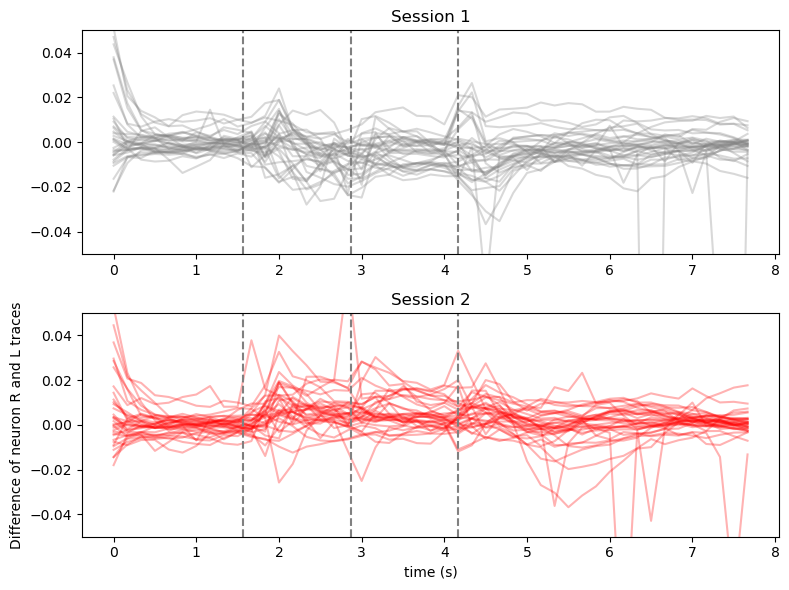

In [76]:
opto_1_diff_abs = np.abs(opto_1_diff_all)
opto_2_diff_abs = np.abs(opto_2_diff_all)

plt.figure(figsize=(8,6))
plt.subplot(211)
# for ix in range(5):
#     plt.plot(tvec, opto_1_diff_abs[ix], alpha=0.3, c='gray')
for ix in range(nfile):
    plt.plot(tvec, opto_P_diff_all[ix], alpha=0.3, c='gray')
# plt.plot(tvec, np.mean(opto_1_diff_abs,axis=0),c='k', lw=2)    
plt.ylim([-0.05,0.05])
plt.axvline(tsample, color='gray', linestyle='--')
plt.axvline(tdelay, color='gray', linestyle='--')
plt.axvline(tresponse, color='gray', linestyle='--')
plt.title('Session 1')
plt.subplot(212)
for ix in range(nfile):
    plt.plot(tvec, opto_A_diff_all[ix], alpha=0.3, c='r')
# plt.plot(tvec, np.mean(opto_2_diff_abs,axis=0),c='r', lw=2)    
plt.ylim([-0.05,0.05])
plt.axvline(tsample, color='gray', linestyle='--')
plt.axvline(tdelay, color='gray', linestyle='--')
plt.axvline(tresponse, color='gray', linestyle='--')
plt.title('Session 2')
plt.xlabel('time (s)')
plt.ylabel('Difference of neuron R and L traces')
plt.tight_layout()



In [19]:
opto_1_diff


array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan])